In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.simplefilter("ignore")

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# converting totalchage into numeric 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [6]:
df['TotalCharges'].isnull().sum()

11

In [7]:
# deleting null vAlues
df.dropna(how='any', inplace=True)

In [8]:
df.drop(['customerID'], axis='columns', inplace=True)
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [9]:
df = pd.get_dummies(df,drop_first=True, dtype='int')
df.head(5)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   gender_Male                            7032 non-null   int32  
 5   Partner_Yes                            7032 non-null   int32  
 6   Dependents_Yes                         7032 non-null   int32  
 7   PhoneService_Yes                       7032 non-null   int32  
 8   MultipleLines_No phone service         7032 non-null   int32  
 9   MultipleLines_Yes                      7032 non-null   int32  
 10  InternetService_Fiber optic            7032 non-null   int32  
 11  InternetS

In [11]:
# considering churn y variable and x variable in other
x = df.drop(['Churn_Yes'], axis=1)
y = df['Churn_Yes']

In [12]:
x

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,1,1,1,1,0,1,...,0,1,0,1,1,0,1,0,0,1
7039,0,72,103.20,7362.90,0,1,1,1,0,1,...,0,1,0,1,1,0,1,1,0,0
7040,0,11,29.60,346.45,0,1,1,0,1,0,...,0,0,0,0,0,0,1,0,1,0
7041,1,4,74.40,306.60,1,1,0,1,0,1,...,0,0,0,0,0,0,1,0,0,1


In [13]:
y


0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn_Yes, Length: 7032, dtype: int32

In [14]:
# split the data inot training and testing
x_train,x_test ,y_train,y_test = train_test_split(x,y, test_size=0.25,random_state=42)

In [20]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

In [21]:
# build the base model 

model_org = LogisticRegression()
model_org.fit(x_train_sc,y_train)

y_pred_org = model_org.predict(x_test_sc)

accuracy_org = accuracy_score(y_pred_org,y_test)*100
print('Accuracy of the base model is: ',round(accuracy_org))

Accuracy of the base model is:  79


## Apply PCA

In [29]:
pca = PCA(n_components=10)
x_train_pca = pca.fit_transform(x_train_sc)
x_test_pca = pca.transform(x_test_sc)

In [30]:
explained_varience = pca.explained_variance_ratio_
print(explained_varience)

[0.33205354 0.11999793 0.09045657 0.04707135 0.04165786 0.0411608
 0.03795099 0.03349116 0.03094919 0.02939063]


In [31]:
# trai n ing the logstic regressiom 

model_pca = LogisticRegression()
model_pca.fit(x_train_pca,y_train)

y_pred_pca = model_pca.predict(x_test_pca)

accuracy_pca = accuracy_score(y_pred_pca,y_test)*100
print('Accuracy of the base model is: ',round(accuracy_org))

Accuracy of the base model is:  79


LOADING DATA
Original Data Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']

First 5 rows:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

STANDARDIZING DATA
Scaled Data Mean: [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Scaled Data Std: [1. 1. 1. 1.]

First 5 rows (scaled):
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]

APPLYING PCA
Explained Variance Ratio:
  PC1: 0.7296 (72.96%)
  PC2: 0.2285 (22.85%)
  PC3: 0.0367 (3.67%)
  PC4: 0.0052 (0.52%)

Cumulative Variance:
  PC1-PC1: 0.7296 (72.96%)
  PC1-PC2: 0.9581 (95.81%)
  PC1-PC3: 0.9948 (99.48%)
  PC1-PC4: 1.0000 (100.00%)

2D PCA Shape: (150, 2)
3D PCA S

Text(0.5, 0, 'Number of Components')

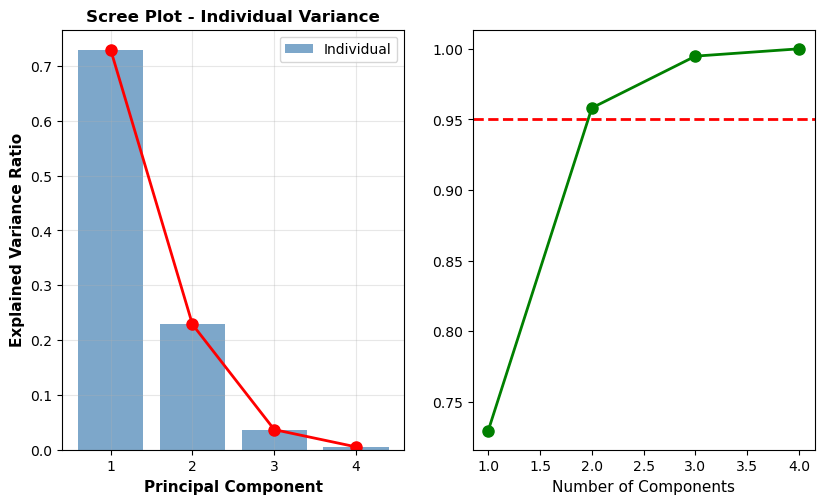

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
import seaborn as sns

# ==================== DATA LOADING ====================
print("=" * 50)
print("LOADING DATA")
print("=" * 50)

# Iris Dataset use kar rahe hain (4 features, 150 samples)
iris = load_iris()
X = iris.data  # Features (4D)
y = iris.target  # Labels (3 classes)
feature_names = iris.feature_names
target_names = iris.target_names

print(f"Original Data Shape: {X.shape}")
print(f"Features: {feature_names}")
print(f"Classes: {target_names}")
print(f"\nFirst 5 rows:\n{X[:5]}")

# ==================== STANDARDIZATION ====================
print("\n" + "=" * 50)
print("STANDARDIZING DATA")
print("=" * 50)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled Data Mean: {X_scaled.mean(axis=0)}")
print(f"Scaled Data Std: {X_scaled.std(axis=0)}")
print(f"\nFirst 5 rows (scaled):\n{X_scaled[:5]}")

# ==================== APPLY PCA ====================
print("\n" + "=" * 50)
print("APPLYING PCA")
print("=" * 50)

# PCA with all components
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# Explained Variance
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Explained Variance Ratio:")
for i, var in enumerate(explained_variance):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")

print(f"\nCumulative Variance:")
for i, cum_var in enumerate(cumulative_variance):
    print(f"  PC1-PC{i+1}: {cum_var:.4f} ({cum_var*100:.2f}%)")

# PCA with 2 components (for visualization)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# PCA with 3 components
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f"\n2D PCA Shape: {X_pca_2d.shape}")
print(f"3D PCA Shape: {X_pca_3d.shape}")

# ==================== GRAPH 1: SCREE PLOT ====================
print("\n" + "=" * 50)
print("CREATING GRAPHS")
print("=" * 50)

fig = plt.figure(figsize=(15, 12))

# Scree Plot
ax1 = plt.subplot(2, 3, 1)
plt.bar(range(1, len(explained_variance) + 1), explained_variance, 
        alpha=0.7, color='steelblue', label='Individual')
plt.plot(range(1, len(explained_variance) + 1), explained_variance, 
         'ro-', linewidth=2, markersize=8)
plt.xlabel('Principal Component', fontsize=11, fontweight='bold')
plt.ylabel('Explained Variance Ratio', fontsize=11, fontweight='bold')
plt.title('Scree Plot - Individual Variance', fontsize=12, fontweight='bold')
plt.xticks(range(1, 5))
plt.grid(True, alpha=0.3)
plt.legend()

# ==================== GRAPH 2: CUMULATIVE VARIANCE ====================
ax2 = plt.subplot(2, 3, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
         'go-', linewidth=2, markersize=8, label='Cumulative')
plt.axhline(y=0.95, color='r', linestyle='--', linewidth=2, label='95% Threshold')
plt.xlabel('Number of Components', fontsize=11)